# **📊 Proyecto TelecomX**

**Análisis de Evasión de Clientes (Churn)**

<br>

---

<br>

**Challenge**: Este desafío forma parte del curso de especialización en Data Science  de [Alura Latam](https://www.aluracursos.com/)

**Formación**: Fundamentos de Python y Datos G9 - ONE

**Alumna**: Aiello Mariana

<br>

**Objetivo del Proyecto:**

Ayudar a la empresa de telecomunicaciones TelecomX a comprender los factores que impulsan la evasión de clientes (churn), mediante un análisis exploratorio de datos (EDA) que permita identificar patrones, obtener insights estratégicos y proporcionar recomendaciones accionables para reducir la tasa de cancelación.

##📌 1. Extracción de datos

El objetivo de esta fase es importar el conjunto de datos `TelecomX_Data.json` al entorno de Google Colab utilizando la biblioteca Pandas. Se realizará la carga de los datos JSON desde la API, convirtiendo a DataFrame de pandas. Se aplicará la normalización de la estructura JSON para obtener un formato tabular adecuado para su posterior limpieza y análisis exploratorio.

### 1.1 Importación de Librerías

Se importan las bibliotecas necesarias para la extracción y manipulación de datos.

In [1]:
# Importación de bibliotecas
import pandas as pd
import json
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Bibliotecas importadas correctamente")

✅ Bibliotecas importadas correctamente


### 1.2 Extracción de Datos desde la API

Se realiza una petición GET a la URL de la APIpara obtener el archivo JSON y se almacena en la variable `datos_json`.

In [2]:
# URL de la API proporcionada
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    # realizar la solicitud GET a la API
    respuesta = requests.get(url)

    # convertir la respuesta a formato JSON
    datos_json = respuesta.json()

    # mostrar resutlados
    print(f"Datos extraídos exitosamente")
    print(f"Tipo de datos: {type(datos_json)}")
    print(f"Número de registros: {len(datos_json)}")

except Exception as e:
    # se captura cualquier error general durante la extracción
    print(f"Error al extraer datos: {e}")


Datos extraídos exitosamente
Tipo de datos: <class 'list'>
Número de registros: 7267


### 1.3 Exploración inicial del JSON

Antes de convertir los datos a un DataFrame de Pandas, se inspecciona la estructura del archivo json. <br>El objetivo es identificar la presencia de posibles datos anidados que requerirán un tratamiento específico durante la carga.

In [3]:
print('=====================')
print('DATAFRAME SIN NORMALIZAR')
print('=====================')

# Inspeccionar la estructura del primer registro del JSON
primer_registro = datos_json[0]
print("\nEstructura del primer registro:")
print(json.dumps(primer_registro, indent=4))

# Convertir JSON en un DataFrame inicial
df_inicial = pd.DataFrame(datos_json)

# Visualizar las dimensiones
print(f"\n📊 Dimensiones del DataFrame sin normalizar: {df_inicial.shape}")
print(f"   - Filas (clientes): {df_inicial.shape[0]}")
print(f"   - Columnas (variables): {df_inicial.shape[1]}\n")

# Visualizar las primeras filas
print("\nPrimeros registros:")
display(df_inicial.head())

# Visualizar las columnas generadas
print("\nColumnas DataFrame inicial:")
print(df_inicial.columns)

# Visualizar la Estructura y tipos de datos
print("\nEstructura y tipos de datos:")
print(df_inicial.info())

DATAFRAME SIN NORMALIZAR

Estructura del primer registro:
{
    "customerID": "0002-ORFBO",
    "Churn": "No",
    "customer": {
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "Yes",
        "tenure": 9
    },
    "phone": {
        "PhoneService": "Yes",
        "MultipleLines": "No"
    },
    "internet": {
        "InternetService": "DSL",
        "OnlineSecurity": "No",
        "OnlineBackup": "Yes",
        "DeviceProtection": "No",
        "TechSupport": "Yes",
        "StreamingTV": "Yes",
        "StreamingMovies": "No"
    },
    "account": {
        "Contract": "One year",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Mailed check",
        "Charges": {
            "Monthly": 65.6,
            "Total": "593.3"
        }
    }
}

📊 Dimensiones del DataFrame sin normalizar: (7267, 6)
   - Filas (clientes): 7267
   - Columnas (variables): 6


Primeros registros:


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."



Columnas DataFrame inicial:
Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

Estructura y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
None


### 1.4 Normalización de estructuras anidadas

Al explorar el `df_inicial` se evidencia que las columnas `customer`, `phone`, `internet` y `account` contienen diccionarios anidados de nivel 1. Para poder manipular y analizar estos datos se aplica la función `pd.json_normalize()`, que **transforma la estructura anidada en un formato tabular** organizando cada clave interna en columnas independientes.

In [4]:
print('=====================')
print('DATAFRAME NORMALIZADO')
print('=====================')

# Aplicar la normalizacion
df_telecom = pd.json_normalize(datos_json)

# Visualizar las dimensiones
print(f"\n📊 Dimensiones del DataFrame: {df_telecom.shape}")
print(f"   - Filas (clientes): {df_telecom.shape[0]}")
print(f"   - Columnas (variables): {df_telecom.shape[1]}\n")

# Visualizar las primeras filas
print("\nPrimeros registros:")
display(df_telecom.head())

# Visualizar las columnas generadas
print("\nColumnas generadas:")
print(df_telecom.columns)

# Visualizar la estructura y los tipos de datos
print("\nEstructura y tipos de datos del DataFrame:")
print(df_telecom.info())

DATAFRAME NORMALIZADO

📊 Dimensiones del DataFrame: (7267, 21)
   - Filas (clientes): 7267
   - Columnas (variables): 21


Primeros registros:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



Columnas generadas:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

Estructura y tipos de datos del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non

### 📊 Resumen de la Extracción

* Datos extraídos exitosamente desde la API de TelecomX  
* Normalización de la estructura JSON anidada a un formato tabular
* **Dimensión final**: 7267 registros (clientes) y 21 columnas (variables)  



## 🔧 2. Transformación de Datos

El objetivo de esta fase es limpiar y procesar los datos extraídos para garantizar su calidad antes del análisis exploratorio. Se realizarán las siguientes tareas:

1. **Explorar la estructura del dataset**: tipos de datos y dimensiones
2. **Renombrar columnas**: simplificar nombres eliminando prefijos del JSON
3. **Detectar incoherencias**: identificar valores nulos, duplicados y errores de formato
4. **Corregir inconsistencias**: estandarizar valores y corregir tipos de datos
5. **Crear columnas derivadas**: calcular cargo diario desde cargo mensual
6. **Estandarizar variables binarias**: convertir valores `Yes/No` o `Female/Male` a formato numérico `1/0`

### 2.1 Exploración inicial de la Estructura del Dataset

Se examina la estructura general del DataFrame para comprender los tipos de datos de cada columna y verificar la cantidad de registros disponibles.

In [5]:
print("INFORMACIÓN GENERAL DEL DATASET")
print("================================")

# Mostrar información general
print("\n📊 Dimensiones del DataFrame:")
print(f"   - Filas: {df_telecom.shape[0]}")
print(f"   - Columnas: {df_telecom.shape[1]}")

print("\nEstructura y tipos de datos:")
df_telecom.info()

print("\nColumnas actuales:")
print(df_telecom.columns)

print("\nPrimeros registros:")
display(df_telecom.head())

INFORMACIÓN GENERAL DEL DATASET

📊 Dimensiones del DataFrame:
   - Filas: 7267
   - Columnas: 21

Estructura y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 n

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#### Variables Relevantes para el Análisis de Churn

Se identifican las vairables más relevantes, en función del objetivo del proyecto (predecir evasión de clientes) y del diccionario de datos.
<br>

**Variable objetivo:** <br>
- `Churn`: Indica si el cliente abandonó la empresa (Yes/No). Es el eje central del análisis.
<br>

**Variables demográficas:** <br>
Ayudan a identificar si el perfil del cliente influye en la evasión o retención.
- `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `tenure`
<br>

**Variables de servicios contratados:** <br>
Permiten analizar si la cantidad o tipo de servicio afectan la decisión.
- `PhoneService`, `MultipleLines`: servicios telefónicos
- `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`: servicios de internet
- `StreamingTV`, `StreamingMovies`: servicios de entretenimiento
<br>

**Variables de facturación y cuenta:**<br>
El aspecto económico y el tipo contrato pueden ser factores claves en la evasión.
- `Contract`: tipo de contrato (mensual, anual, bianual)
- `PaperlessBilling`: tipo de facturación
- `PaymentMethod`: método de pago
- `Charges_Monthly`, `Charges_Total`: información financiera del cliente

<br>

### 2.2 Renombramiento de Columnas

Se simplifican los nombres de las columnas, eliminando los prefijos generados por el JSON anidado (ej. `customer.`, `phone.`, `internet.`, `account.`). El objetivo es facilitar la posterior manipulación y análisis de los datos, así como mejorar la legibilidad del código y reducir la posibilidad de errores.


In [6]:
print("RENOMBRANDO LAS COLUMNAS")
print("========================")

# Diccionario para renombrar y estandarizar columnas
cols_rename = {
    'customerID': 'customer_id',
    'Churn': 'churn',
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'senior_citizen',
    'customer.Partner': 'partner',
    'customer.Dependents': 'dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'phone_service',
    'phone.MultipleLines': 'multiple_lines',
    'internet.InternetService': 'internet_service',
    'internet.OnlineSecurity': 'online_security',
    'internet.OnlineBackup': 'online_backup',
    'internet.DeviceProtection': 'device_protection',
    'internet.TechSupport': 'tech_support',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_movies',
    'account.Contract': 'contract',
    'account.PaperlessBilling': 'paperless_billing',
    'account.PaymentMethod': 'payment_method',
    'account.Charges.Monthly': 'monthly_charges',
    'account.Charges.Total': 'total_charges'
}

# Aplicar el renombramiento
df_telecom = df_telecom.rename(columns=cols_rename)

# Mostrar nuevos nombres
print("\nNuevas columnas:")
print(df_telecom.columns)

RENOMBRANDO LAS COLUMNAS

Nuevas columnas:
Index(['customer_id', 'churn', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges'],
      dtype='object')


### 2.3 Detección de Incoherencias

Se verifica la calidad de los datos identificando posibles problemas que puedan afectar el análisis posterior. Esto incluye identiifcar la presencia de valores nulos, registros duplicados, errores de formato u otras inconsistencias en las categorías.

#### 2.3.1 Análisis de Registros Duplicados

Se verifica si existen registros duplicados en el dataset basándose en el identificador único de cliente (`customerID`).

In [7]:
print("ANÁLISIS DE DUPLICADOS")
print("======================")

# Verificar dclientes duplicados (por su identificador unico)
duplicados = df_telecom['customer_id'].duplicated().sum()
print(f"\nRegistros con customer_id duplicado: {duplicados}")

# Mostrar mensaje con resultados
if duplicados > 0:
    print("\nSe detectaron IDs duplicados que requieren investigación")
else:
    print("\nNo se detectaron duplicados")


ANÁLISIS DE DUPLICADOS

Registros con customer_id duplicado: 0

No se detectaron duplicados


#### 2.3.2 Análisis de Valores Nulos

Se verifica la presencia de valores nulos en el dataset.

In [8]:
print("ANÁLISIS DE VALORES NULOS")
print("=========================")

# Contar valores nulos por columna
nulos_col = df_telecom.isnull().sum()
nulos_totales = nulos_col.sum()
print(f"\nValores nulos por columna:\n {nulos_col }")
print(f"\nTotal de valores nulos en el dataset: {nulos_totales}")


# Mostrar solo columnas con valores nulos (si existen)
if nulos_totales > 0:
    print("\nColumnas con valores nulos:")
    print(nulos_col[nulos_col > 0])
else:
    print("\nNo se detectaron valores nulos en el dataset")

ANÁLISIS DE VALORES NULOS

Valores nulos por columna:
 customer_id          0
churn                0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
dtype: int64

Total de valores nulos en el dataset: 0

No se detectaron valores nulos en el dataset


#### 2.3.3 Validación de Formatos y Valores Inconsistentes

Se analizan las columnas del dataset para identificar inconsistencias en formatos y valores inesperados, tanto en variables categóricas como numéricas.

In [9]:
print("EXPLORACIÓN DE VALORES ÚNICOS")
print("==========================")

# Seleccionar columnas tipo object (categóricas)
columnas_categoricas = df_telecom.select_dtypes(include='object').columns

for col in columnas_categoricas:
    valores_unicos = df_telecom[col].unique()

    print(f"\n• {col}:")
    print(f"   Cantidad de valores únicos: {len(valores_unicos)}")

    # Mostrar los valores únicos (si son pocos)
    if len(valores_unicos) <= 10:
        print(f"   Valores: {sorted(valores_unicos)}")
    else:
        print(f"   Primeros 10 valores: {sorted(valores_unicos)[:10]}")

EXPLORACIÓN DE VALORES ÚNICOS

• customer_id:
   Cantidad de valores únicos: 7267
   Primeros 10 valores: ['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS']

• churn:
   Cantidad de valores únicos: 3
   Valores: ['', 'No', 'Yes']

• gender:
   Cantidad de valores únicos: 2
   Valores: ['Female', 'Male']

• partner:
   Cantidad de valores únicos: 2
   Valores: ['No', 'Yes']

• dependents:
   Cantidad de valores únicos: 2
   Valores: ['No', 'Yes']

• phone_service:
   Cantidad de valores únicos: 2
   Valores: ['No', 'Yes']

• multiple_lines:
   Cantidad de valores únicos: 3
   Valores: ['No', 'No phone service', 'Yes']

• internet_service:
   Cantidad de valores únicos: 3
   Valores: ['DSL', 'Fiber optic', 'No']

• online_security:
   Cantidad de valores únicos: 3
   Valores: ['No', 'No internet service', 'Yes']

• online_backup:
   Cantidad de valores únicos: 3
   Valores: ['No', 'No internet servi

In [10]:
print("VALIDACIÓN DE FORMATO 'CUSTOMER_ID'")
print("===================================\n")

# Patrón esperado: 4 dígitos, un guion, 5 letras
patron_id = r'^\d{4}-[A-Za-z]{5}$'
id_invalidos = df_telecom[~df_telecom['customer_id'].str.contains(patron_id, regex=True, na=False)]

print(f"Registros con ID cliente fuera de formato: {len(id_invalidos)}")
if len(id_invalidos) > 0:
    print(id_invalidos['customer_id'].head())


VALIDACIÓN DE FORMATO 'CUSTOMER_ID'

Registros con ID cliente fuera de formato: 0


In [11]:
print("VALIDACIÓN DE VALORES CATEGÓRICOS")
print("==================================\n")

# Diccionario con valores esperados
valores_esperados = {
    'churn': ['Yes', 'No'],
    'gender': ['Male', 'Female'],
    'partner': ['Yes', 'No'],
    'dependents': ['Yes', 'No'],
    'phone_service': ['Yes', 'No'],
    'multiple_lines': ['Yes', 'No', 'No phone service'],
    'internet_service': ['DSL', 'Fiber optic', 'No'],
    'online_security': ['Yes', 'No', 'No internet service'],
    'online_backup': ['Yes', 'No', 'No internet service'],
    'device_protection': ['Yes', 'No', 'No internet service'],
    'tech_support': ['Yes', 'No', 'No internet service'],
    'streaming_tv': ['Yes', 'No', 'No internet service'],
    'streaming_movies': ['Yes', 'No', 'No internet service'],
    'contract': ['Month-to-month', 'One year', 'Two year'],
    'paperless_billing': ['Yes', 'No'],
    'payment_method': ['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
                       'Credit card (automatic)']
}


# Validar cada columna
for col, validos in valores_esperados.items():
    cant_invalidos = (~df_telecom[col].isin(validos)).sum()

    # Mostrar solo columnas con valores inválidos
    if cant_invalidos > 0:
        vacios = (df_telecom[col] == '').sum()
        porcentaje = (cant_invalidos / len(df_telecom)) * 100

        print(f"• {col}: {cant_invalidos} valores inválidos ({porcentaje:.2f}% del total)")
        if vacios > 0:
            print(f"   ↳ {vacios} corresponden a valores vacíos")

VALIDACIÓN DE VALORES CATEGÓRICOS

• churn: 224 valores inválidos (3.08% del total)
   ↳ 224 corresponden a valores vacíos


In [12]:
print("VALIDACIÓN DE VALORES NUMÉRICOS")
print("================================\n")

# 1. Verificar senior_citizen (debe ser 0 o 1)
valores_senior = df_telecom['senior_citizen'].unique()
invalidos_senior = (~df_telecom['senior_citizen'].isin([0, 1])).sum()
print("• senior_citizen (debe ser 0 o 1):")
print(f"    Valores únicos: {sorted(valores_senior.tolist())}")
print(f"    Registros con valores inválidos: {invalidos_senior}\n")


# 2. Verificar monthly_charges (debe ser numérico positivo)
print("• tenure (debe ser numérico y positivo):")
print(f"    Tipo de dato: {df_telecom['tenure'].dtype}")
print(f"    Rango: {df_telecom['tenure'].min()} - {df_telecom['tenure'].max()}")

negativos = (df_telecom['tenure'] < 0).sum()
print(f"    Registros con valores negativos: {negativos}\n")


# 3. Verificar monthly_charges (debe ser numérico positivo)
print("• monthly_charges (debe ser numérico y positivo):")
print(f"    Tipo de dato: {df_telecom['monthly_charges'].dtype}")
print(f"    Rango: {df_telecom['monthly_charges'].min()} - {df_telecom['monthly_charges'].max()}")

negativos = (df_telecom['monthly_charges'] < 0).sum()
print(f"    Registros con valores negativos: {negativos}\n")


# 4. Verificar total_charges (debería ser numérico pero es object)
print("• total_charges (debería ser numérico):")
print(f"    Tipo de dato actual: {df_telecom['total_charges'].dtype}")
print(f"    Valores únicos: {df_telecom['total_charges'].nunique()}")

# Detectar valores no numéricos
patron_numerico = r'^\d+(\.\d+)?$'
filtro_no_numerico = ~df_telecom['total_charges'].str.match(patron_numerico, na=False)
cant_no_numericos = filtro_no_numerico.sum()
print(f"    Registros con valores no numéricos: {cant_no_numericos}")

if cant_no_numericos > 0:
    valores_no_numericos = df_telecom.loc[filtro_no_numerico, 'total_charges'].unique()
    print(f"    Valores no numéricos encontrados: {valores_no_numericos}")


VALIDACIÓN DE VALORES NUMÉRICOS

• senior_citizen (debe ser 0 o 1):
    Valores únicos: [0, 1]
    Registros con valores inválidos: 0

• tenure (debe ser numérico y positivo):
    Tipo de dato: int64
    Rango: 0 - 72
    Registros con valores negativos: 0

• monthly_charges (debe ser numérico y positivo):
    Tipo de dato: float64
    Rango: 18.25 - 118.75
    Registros con valores negativos: 0

• total_charges (debería ser numérico):
    Tipo de dato actual: object
    Valores únicos: 6531
    Registros con valores no numéricos: 11
    Valores no numéricos encontrados: [' ']


##### Análisis de registros con `total_charges` vacío

* Se investiga la relación entre los valores vacíos de `total_charges` y otras variables para determinar la estrategia de corrección más apropiada.

In [13]:
print("ANÁLISIS DE REGISTROS CON total_charges VACÍO")
print("==============================================\n")

# Filtrar registros con valores vacíos en 'total_charges'
filas_problema = df_telecom[df_telecom['total_charges'] == ' ']
print(f"Total de registros afectados: {len(filas_problema)}\n")

# Valores de 'churn' en estos registros
print(f"Valores de 'churn' en registros problemáticos: {filas_problema['churn'].unique()}")

# Valores de 'tenure' en estos registros
print(f"\nValores de 'tenure' en registros problemáticos: {filas_problema['tenure'].unique()}")


ANÁLISIS DE REGISTROS CON total_charges VACÍO

Total de registros afectados: 11

Valores de 'churn' en registros problemáticos: ['No']

Valores de 'tenure' en registros problemáticos: [0]


### 2.4 Corrección de Inconsistencias

A partir de los problemas detectados, se aplican las siguientes correcciones:

1. **Variable Target (`churn`):** se eliminan los registros con valores vacíos. Al tratarse de la variable principal de análisis, no se pueden rellenar los datos faltantes ya que esto generaría sesgos en los resultados.La eliminación de estas filas solo representa el 3% del dataset.

2. **Facturación Total (`total_charges`):** se reemplazan los 11 registros con valores vacíos por `0` y luego se convierte la columna de tipo `object` a formato numérico (`float64`). El análisis previo confirmó que estos registros corresponden a clientes con `tenure = 0` (clientes nuevos que aún no completaron su primer mes de servicio), por lo que su facturación total acumulada es cero.

In [14]:
print("CORRECCIÓN DE INCONSISTENCIAS DETECTADAS")
print("=========================================\n")


# Corrección en 'churn'
print("• CHURN: eliminar registros vacíos")
registros_iniciales = len(df_telecom)
df_telecom = df_telecom[df_telecom['churn'].isin(['Yes', 'No'])]
registros_finales = len(df_telecom)

print(f" --> Registros eliminados: {registros_iniciales - registros_finales}")
print(f" --> Registros restantes: {registros_finales}\n")


# Corrección en 'total_charges'
print("• TOTAL_CHARGES: reemplazar registros vacíos por 0")
df_telecom['total_charges'] = df_telecom['total_charges'].replace(' ', '0')
df_telecom['total_charges'] = df_telecom['total_charges'].astype(float)

print(f" --> Nuevo tipo de dato: {df_telecom['total_charges'].dtype}\n\n")


df_telecom.info()

CORRECCIÓN DE INCONSISTENCIAS DETECTADAS

• CHURN: eliminar registros vacíos
 --> Registros eliminados: 224
 --> Registros restantes: 7043

• TOTAL_CHARGES: reemplazar registros vacíos por 0
 --> Nuevo tipo de dato: float64


<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   churn              7043 non-null   object 
 2   gender             7043 non-null   object 
 3   senior_citizen     7043 non-null   int64  
 4   partner            7043 non-null   object 
 5   dependents         7043 non-null   object 
 6   tenure             7043 non-null   int64  
 7   phone_service      7043 non-null   object 
 8   multiple_lines     7043 non-null   object 
 9   internet_service   7043 non-null   object 
 10  online_security    7043 non-null   object 
 11  online_backup      7043 non-null   object 


### 2.5 Creación de Atributos (Cuentas Diarias)

Se genera una nueva variable numérica `charges_daily` que representa el **costo diario estimado del servicio** para cada cliente. Este valor se calcula dividiendo el cargo mensual (`monthly_charges`) entre 30 días, lo que permite analizar la facturación con un mayor nivel de detalle.

In [15]:
print("CREACIÓN DE NUEVA VARIABLE")
print("==========================\n")

# Creación por asignación directa
df_telecom['cuentas_diarias'] = round(df_telecom['monthly_charges'] / 30, 2)
print("• Columna 'cuentas_diarias' creada exitosamente.\n")

# Visualizar las columnas implicadas
display(df_telecom[['monthly_charges', 'cuentas_diarias']].head())


CREACIÓN DE NUEVA VARIABLE

• Columna 'cuentas_diarias' creada exitosamente.



,monthly_charges,cuentas_diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


### 2.6 Estandarización de Variables Binarias

Para facilitar análisis posteriores, se transforman las variables con valores binarios (`Yes/No`) a formato numérico (`1/0`), donde `1` representa afirmativo y `0` representa negativo. También se convierte la variable `gender` siguiendo el mismo criterio (Female: 1, Male: 0).

In [16]:
print("ESTANDARIZACIÓN DE VARIABLES BINARIAS")
print("=====================================\n")

# Columnas binarias: convertir Yes/No a 1/0
columnas_binarias = ['churn', 'partner', 'dependents', 'phone_service', 'paperless_billing']

for col in columnas_binarias:
    df_telecom[col] = df_telecom[col].map({'Yes': 1, 'No': 0}).astype(int)


# Columna 'gender': convertir Female/Male a 1/0
df_telecom['gender'] = df_telecom['gender'].map({'Female': 1, 'Male': 0}).astype(int)

print("• Transformación completada: Yes/No -> 1/0")
print("• Transformación completada: Female/Male -> 1/0")


# Comprobación del cambio de tipos de dato
print("\nDataFrame actualizado:")
print(df_telecom.info())

print("\nPrimeros registros transformados:")
display(df_telecom[['gender'] + columnas_binarias].head())

ESTANDARIZACIÓN DE VARIABLES BINARIAS

• Transformación completada: Yes/No -> 1/0
• Transformación completada: Female/Male -> 1/0

DataFrame actualizado:
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   churn              7043 non-null   int64  
 2   gender             7043 non-null   int64  
 3   senior_citizen     7043 non-null   int64  
 4   partner            7043 non-null   int64  
 5   dependents         7043 non-null   int64  
 6   tenure             7043 non-null   int64  
 7   phone_service      7043 non-null   int64  
 8   multiple_lines     7043 non-null   object 
 9   internet_service   7043 non-null   object 
 10  online_security    7043 non-null   object 
 11  online_backup      7043 non-null   object 
 12  device_protection  7043 non-null   object 
 13  tech_support       

,gender,churn,partner,dependents,phone_service,paperless_billing
0,1,0,1,1,1,1
1,0,0,0,0,1,0
2,0,1,0,0,1,1
3,0,1,1,0,1,1
4,1,1,1,0,1,1


**Resumen de la transformación:**

Se convirtieron exitosamente 6 variables a formato binario:
- **Variables Yes/No:** `churn`, `partner`, `dependents`, `phone_service`, `paperless_billing`
- **Variable de género:** `gender` (Female/Male)

Las variables con tres valores (como multiple_lines, servicios de internet y streaming) se mantienen en su formato categórico original para preservar la información sobre ausencia de servicio vs. no contratación del mismo.

## 📊 3. Carga y Análisis Exploratorio de Datos

Con los datos limpios y estandarizados, se procede al análisis exploratorio para comprender el comportamiento de los clientes y los factores asociados a la evasión (churn), mediante el uso de estadísticas descriptivas y visualizaciones gráficas. Esta fase incluye cuatro etapas:

1. **Análisis descriptivo**: estadísticas generales del dataset
2. **Distribución de churn**: proporción de clientes que abandonaron vs. permanecieron
3. **Churn por variables categóricas**: patrones de evasión según el perfil del cliente.
4. **Churn por variables numéricas**: impacto de la antigüedad y la facturación en la decisión de abandonar el servicio.
5. **Análisis de correlación**: evaluación de las relaciones estadísticas lineales entre las variables cuantitativas y la tasa de abandono.


### 3.1 Análisis Descriptivo General

Se calculan las estadísticas descriptivas principales (media, mediana, desviación estándar, valores mínimos y máximos) para las variables numéricas del dataset. Esto permite comprender la distribución de los datos y obtener una visión general del comportamiento de los clientes.

In [17]:
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("================================================\n")

# Variables numéricas a analizar
vars_numericas = ['senior_citizen', 'tenure', 'monthly_charges', 'total_charges', 'cuentas_diarias']

# Mostrar estadísticas descriptivas
estadisticas = df_telecom[vars_numericas].describe().round(2)
display(estadisticas)



print("\nRESUMEN DE LA VARIABLE OBJETIVO (CHURN)\n")
total_clientes = len(df_telecom)
churn_si = df_telecom['churn'].sum()
churn_no = total_clientes - churn_si

porcentaje_si = (churn_si / total_clientes) * 100
porcentaje__no = (churn_no / total_clientes) * 100

# Impresión de resultados
print(f"• Total de clientes válidos: {total_clientes}")
print(f"• Clientes que abandonaron (1): {churn_si} ({porcentaje_si:.1f}%)")
print(f"• Clientes que permanecieron (0): {churn_no} ({porcentaje:.1f}%)")

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS



,senior_citizen,tenure,monthly_charges,total_charges,cuentas_diarias
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73,2.16
std,0.37,24.56,30.09,2266.79,1.00
min,0.00,0.00,18.25,0.00,0.61
25%,0.00,9.00,35.50,398.55,1.18
50%,0.00,29.00,70.35,1394.55,2.34
75%,0.00,55.00,89.85,3786.60,2.99
max,1.00,72.00,118.75,8684.80,3.96



RESUMEN DE LA VARIABLE OBJETIVO (CHURN)

• Total de clientes válidos: 7043
• Clientes que abandonaron (1): 1869 (26.5%)
• Clientes que permanecieron (0): 5174 (3.1%)


**Interpretación de las Estadísticas Descriptivas:**
<br>

* **Antigüedad de clientes (`tenure`):** El cliente promedio tiene una antigüedad de 32 meses (casi 3 años), con un máximo de retención de 72 meses (6 años). Sin embargo, al observar el primer cuartil (25%), notamos que una cuarta parte de la base tiene 9 meses o menos. Esto indica que hay un gran volumen de usuarios nuevos, una etapa que suele ser crítica para la retención.

* **Facturación Mensual (`monthly_charges`):** El ticket promedio de la empresa es de ~\$64.7 dólares mensuales. Existe una enorme brecha entre el plan más barato (\$18.25) y el más caro (\$118.75), lo que confirma que la empresa ofrece desde servicios muy básicos (probablemente solo teléfono) hasta paquetes premium completos. La mediana (50%) nos muestra que la mitad de los clientes paga $70 o menos.

* **Tasa de Evasión Base (`churn`):** A partir del conteo directo, se revela que el **26.5%** de los clientes válidos abandonaron el servicio. Esto significa que la empresa está perdiendo a más de 1 de cada 4 clientes, una cifra alarmante que justifica la necesidad urgente de este análisis.

### 3.2 Distribución de Evasión (Churn)

Se analiza la distribución de la variable objetivo `churn` para comprender la proporción de clientes que abandonaron el servicio frente a los que permanecieron. Se grafican los contenidos para dimensionar visualmente el impacto de las cancelaciones.


ANÁLISIS DE DISTRIBUCIÓN DE CHURN



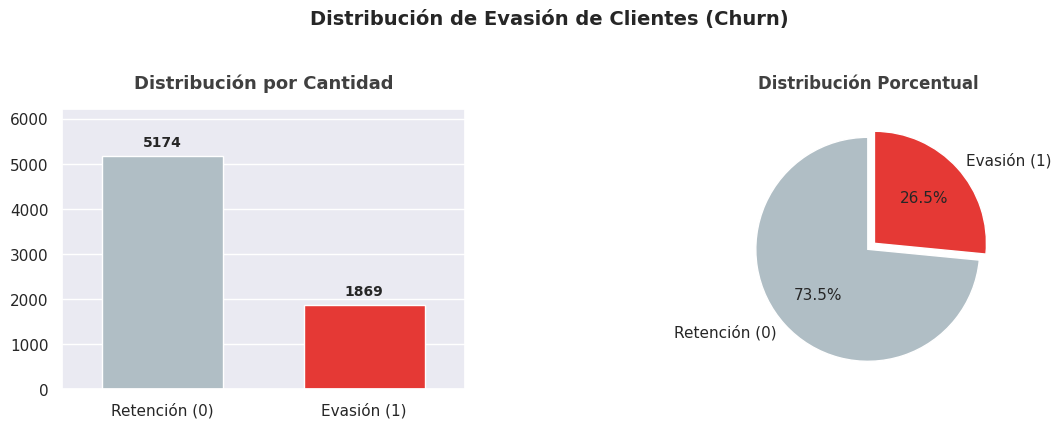


RESUMEN NUMÉRICO:
  Retención (0): 5174 clientes (73.46%)
  Evasión (1): 1869 clientes (26.54%)


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

print("ANÁLISIS DE DISTRIBUCIÓN DE CHURN")
print("==================================\n")

# Variables de conteo y fecuencia
conteo_evasion = df_telecom['churn'].value_counts()
total_clientes = len(df_telecom)
porcentaje_evasion = (conteo_evasion / total_clientes * 100).round(2)

etiquetas = ['Retención (0)', 'Evasión (1)']
valores = [conteo_evasion.get(0, 0), conteo_evasion.get(1, 0)]
porcentajes = [porcentaje_evasion.get(0, 0), porcentaje_evasion.get(1, 0)]

# Colores: rojo evasión - gris retención
colores_alerta = ['#B0BEC5', '#E53935']

# Crear lienzo
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 4))
fig.suptitle('Distribución de Evasión de Clientes (Churn)', fontsize=14, fontweight='bold', y=1.10)

# Gráfico de Barras
sns.barplot(x=etiquetas, y=valores, hue=etiquetas, palette=colores_alerta, ax=axes[0], saturation=1, width=0.6, legend=False)
axes[0].set_title('Distribución por Cantidad', fontsize=13, pad=15, fontweight='bold', color='#404040')
axes[0].set_ylim(0, max(valores) * 1.20)
axes[0].set(ylabel=None, xlabel=None)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold',
                     xytext=(0, 5), textcoords='offset points')


# Gráfico de Torta
axes[1].pie(valores, labels=etiquetas, autopct='%1.1f%%', startangle=90,
            colors=colores_alerta, explode=(0, 0.08),
            textprops={'fontsize': 11})
axes[1].set_title('Distribución Porcentual', fontsize=12, pad=15, fontweight='bold', color='#404040')


# mostrar gráfico
plt.subplots_adjust(top=0.85, bottom=0.15, wspace=0.5)
plt.show()

# mostrar resumen
print("\nRESUMEN NUMÉRICO:")
for i in range(len(etiquetas)):
    print(f"  {etiquetas[i]}: {valores[i]} clientes ({porcentajes[i]}%)")

**Interpretación de la Distribución:**

La tasa de evasión del **26.5%** indica que la empresa enfrenta un desafío considerable en retención de clientes. Si bien el **73.5%** de clientes retenidos representa una base estable, perder a más de 1 de cada 4 clientes implica una pérdida significativa de ingresos y potencial de crecimiento. En industrias de servicios por suscripción, una tasa cercana al 25-30% suele considerarse elevada, lo que refuerza la necesidad de identificar los factores que impulsan esta evasión para diseñar estrategias de retención más efectivas.

### 3.3 Análisis de Churn por Variables Categóricas

Se explora cómo se distribuye la evasión según diferentes características categóricas de los clientes (género, tipo de contrato, servicios contratados, método de pago, etc.). Este análisis permite identificar perfiles de clientes con mayor propensión a abandonar el servicio.

Se analizarán las siguientes variables:
- **Perfil demográfico**: género, edad (mayores de 60 años), estado civil (tiene pareja)
- **Características del contrato**: tipo de contrato, método de pago
- **Servicios contratados**: tipo de servicio de internet


**Configuración Inicial y Funciones Auxiliares**

Se configuran las librerías gráficas y la paleta de colores (rojo para evasión, gris para retención) para mantener consistencia visual en todo el análisis.

Se define la función `tabla_resumen_churn` que automatiza la creación de tablas de contingencia unificadas. Esto permite visualizar simultáneamente el volumen absoluto de clientes y la tasa de evasión relativa en un formato limpio y directo.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
colores_alerta = ['#B0BEC5', '#E53935'] # rojo eviasión, gris retención
colores_pie = ['#CFD8DC', '#636EFA'] # gris claro y azul

# Función para generar tablas de resumen
def tabla_resumen_churn(df, columna, mapeo=None, titulo=None):
    # crear tabla cruzada (con totales absolutos)
    resumen = pd.crosstab(df[columna], df['churn'], margins=True, margins_name='Total General')
    resumen.columns = ['Retenidos (0)', 'Evadidos (1)', 'Total Clientes']

    # reordenar columnas y calcular porcentaje
    resumen = resumen[['Total Clientes', 'Retenidos (0)', 'Evadidos (1)']]
    resumen['Tasa de Evasión'] = (resumen['Evadidos (1)'] / resumen['Total Clientes'] * 100).round(2).astype(str) + '%'

    # aplicar nombres legibles al índice
    if mapeo and columna in mapeo:
        resumen.index = [mapeo[columna].get(x, x) if x != 'Total General' else x for x in resumen.index]

    print(f"\nResumen de Churn por: {titulo if titulo else columna.upper()}")
    display(resumen)

#### 3.3.1 Churn por Perfil Demográfico

Se analiza si el perfil demográfico del cliente influye en su decisión de abandonar la empresa. <br>Se evalúa el género, la edad (adultos mayores) y el estado de convivencia de los clientes.


CONTEXTO POBLACIONAL



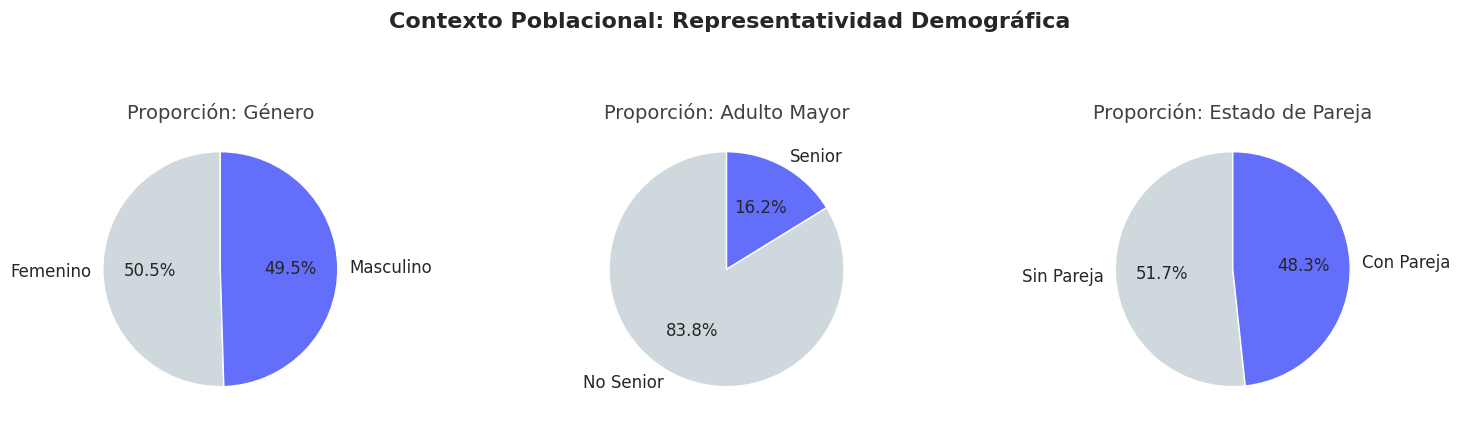

In [20]:
print("CONTEXTO POBLACIONAL")
print("====================\n")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# variables y diccionarios
vars_demograficas = ['gender', 'senior_citizen', 'partner']

mapeo_demo = {
    'gender': {0: 'Femenino', 1: 'Masculino', 'Female': 'Femenino', 'Male': 'Masculino'},
    'senior_citizen': {0: 'No Senior', 1: 'Senior'},
    'partner': {0: 'Sin Pareja', 1: 'Con Pareja', 'No': 'Sin Pareja', 'Yes': 'Con Pareja'}
}

titulos_demo = {'gender': 'Género', 'senior_citizen': 'Adulto Mayor', 'partner': 'Estado de Pareja'}
colores_pie = ['#CFD8DC', '#636EFA']

# crear GRÁFICO TORTA
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))
fig.suptitle('Contexto Poblacional: Representatividad Demográfica', fontsize=16, fontweight='bold', y=0.88)

for i, col in enumerate(vars_demograficas):
    conteo = df_telecom[col].value_counts()
    etiquetas = [mapeo_demo[col].get(x, x) for x in conteo.index]

    axes[i].pie(conteo, labels=etiquetas, autopct='%1.1f%%', startangle=90,
                colors=colores_pie, wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 12})
    axes[i].set_title(f"Proporción: {titulos_demo[col]}", fontsize=14, pad=0, color='#404040')

plt.tight_layout(pad=2.0, w_pad=3.0, rect=[0, 0, 1, 0.85])
plt.show()

PERFIL DEMOGRÁFICO VS. EVASIÓN



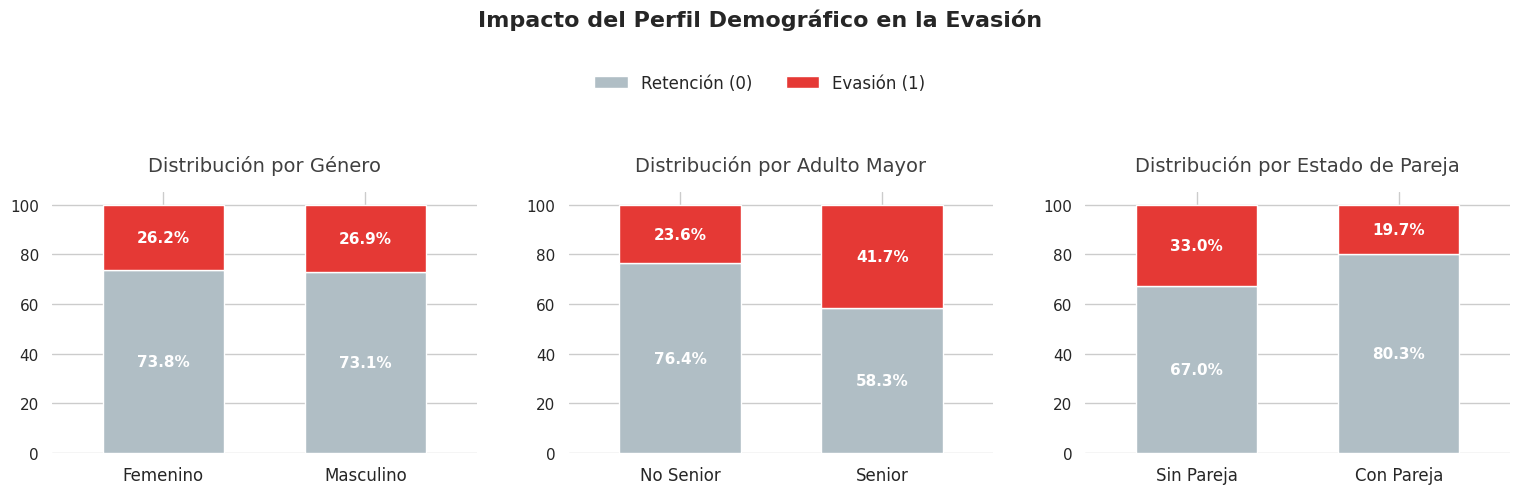




Resumen de Churn por: GÉNERO


,Total Clientes,Retenidos (0),Evadidos (1),Tasa de Evasión
Femenino,3555,2625,930,26.16%
Masculino,3488,2549,939,26.92%
Total General,7043,5174,1869,26.54%





Resumen de Churn por: ADULTO MAYOR


,Total Clientes,Retenidos (0),Evadidos (1),Tasa de Evasión
No Senior,5901,4508,1393,23.61%
Senior,1142,666,476,41.68%
Total General,7043,5174,1869,26.54%





Resumen de Churn por: ESTADO DE PAREJA


,Total Clientes,Retenidos (0),Evadidos (1),Tasa de Evasión
Sin Pareja,3641,2441,1200,32.96%
Con Pareja,3402,2733,669,19.66%
Total General,7043,5174,1869,26.54%


In [21]:
print("PERFIL DEMOGRÁFICO VS. EVASIÓN")
print("==============================\n")

colores_alerta = ['#B0BEC5', '#E53935']

# Crear GRÁFICO BARRAS
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))
fig.suptitle('Impacto del Perfil Demográfico en la Evasión', fontsize=16, fontweight='bold', y=1.05)

for i, col in enumerate(vars_demograficas):
    # agrupación y normalización
    tabla_prop = pd.crosstab(df_telecom[col], df_telecom['churn'], normalize='index') * 100

    # mapear nombres para el eje X
    if col in mapeo_demo:
        tabla_prop.index = tabla_prop.index.map(lambda x: mapeo_demo[col].get(x, x))

    # crear gráfico
    tabla_prop.plot(kind='bar', stacked=True, color=colores_alerta, ax=axes[i], legend=False, width=0.6)

    # estética gráfico
    axes[i].set_title(f'Distribución por {titulos_demo[col]}', fontsize=14, pad=15, color='#404040')
    axes[i].set(ylabel=None, xlabel=None)
    axes[i].tick_params(axis='x', rotation=0, labelsize=12)
    sns.despine(ax=axes[i], left=True, bottom=True)

    # porcentajes en barras
    for p in axes[i].patches:
        ancho, alto = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if alto > 5:
            axes[i].text(x + ancho/2, y + alto/2, f'{alto:.1f}%',
                         ha='center', va='center', color='white', fontweight='bold', fontsize=11)

fig.legend(['Retención (0)', 'Evasión (1)'], loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, frameon=False, fontsize=12)
plt.tight_layout(pad=3.0, w_pad=3.0)
plt.show()



# TABLAS DE RESUMEN
for col in vars_demograficas:
    print(f"\n\n\nResumen de Churn por: {titulos_demo[col].upper()}")

    # tabla cruzada con Totales absolutos
    resumen = pd.crosstab(df_telecom[col], df_telecom['churn'], margins=True, margins_name='Total General')
    resumen.columns = ['Retenidos (0)', 'Evadidos (1)', 'Total Clientes']

    # Reordenar y calcular porcentaje
    resumen = resumen[['Total Clientes', 'Retenidos (0)', 'Evadidos (1)']]
    resumen['Tasa de Evasión'] = (resumen['Evadidos (1)'] / resumen['Total Clientes'] * 100).round(2).astype(str) + '%'

    # Insertar nombres legibles
    if col in mapeo_demo:
        resumen.index = [mapeo_demo[col].get(x, x) if x != 'Total General' else x for x in resumen.index]

    display(resumen)

**Conclusiones - Perfil Demográfico:**

* **Género:** no existe una diferencia significativa en la tasa de evasión entre hombres y mujeres (ambos rondan la media general del ~26%). Esta variable no parece ser un factor determinante para el churn.

* **Edad:** los adultos mayores (senior_citizen=1) presentan una tasa de abandono mucho más alta (41.68%) que los clientes más jóvenes. Sin embargo, el análisis poblacional muestra que este grupo representa una minoría en la base total (~16%), por lo que su impacto en el abandono global es más limitado, aunque podría requerir estrategias de retención específicas.

* **Estado Civil:** Los clientes sin pareja (`partner=0`) muestran mayor tendencia a cancelar el servicio en comparación con aquellos que sí tienen pareja (32.96% vs 19.66%). Esto sugiere una mayor estabilidad en la permanencia en la empresa por parte de los clientes que tienen pareja.

#### 3.3.2 Churn por Características del Contrato

Se evalúa cómo las condiciones del contrato influyen en la decisión de abandonar la empresa, considerando el **tipo de contrato** y el **método de pago** elegido por el cliente

CONTEXTO POBLACIONAL



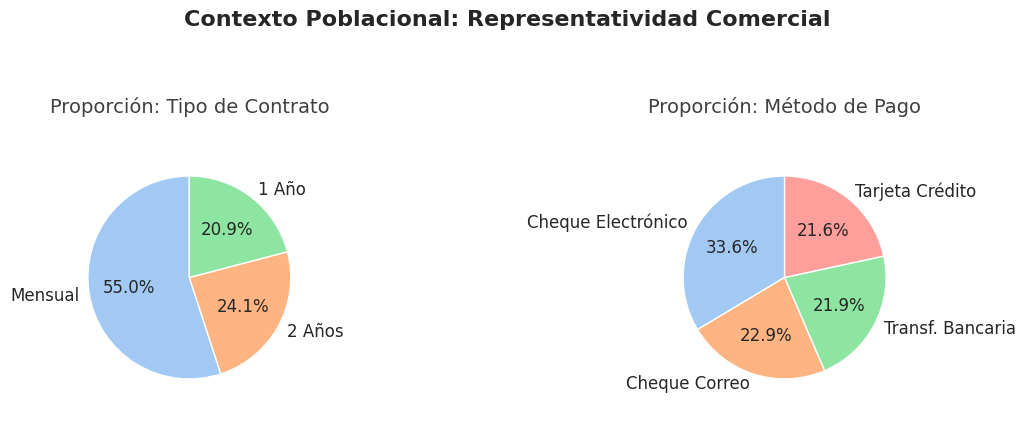

In [22]:
print("CONTEXTO POBLACIONAL")
print("====================\n")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# variables y diccionarios
vars_comerciales = ['contract', 'payment_method']

mapeo_comercial = {
    'contract': {'Month-to-month': 'Mensual', 'One year': '1 Año', 'Two year': '2 Años'},
    'payment_method': {'Electronic check': 'Cheque Electrónico', 'Mailed check': 'Cheque Correo',
                       'Bank transfer (automatic)': 'Transf. Bancaria', 'Credit card (automatic)': 'Tarjeta Crédito'}
}

titulos_comercial = {'contract': 'Tipo de Contrato', 'payment_method': 'Método de Pago'}
colores_pie_comercial = sns.color_palette("pastel")[0:4]

# crear GRÁFICO TORTA
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
fig.suptitle('Contexto Poblacional: Representatividad Comercial', fontsize=16, fontweight='bold', y=0.92)

for i, col in enumerate(vars_comerciales):
    conteo = df_telecom[col].value_counts()
    etiquetas = [mapeo_comercial[col].get(x, x) for x in conteo.index]

    axes[i].pie(conteo, labels=etiquetas, autopct='%1.1f%%', startangle=90, radius=0.8,
                colors=colores_pie_comercial, wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 12})
    axes[i].set_title(f"Proporción: {titulos_comercial[col]}", fontsize=14, pad=5, color='#404040')

plt.tight_layout(pad=2.0, w_pad=3.0, rect=[0, 0, 1, 0.92])
plt.show()

CONTRATO Y PAGO VS. EVASIÓN



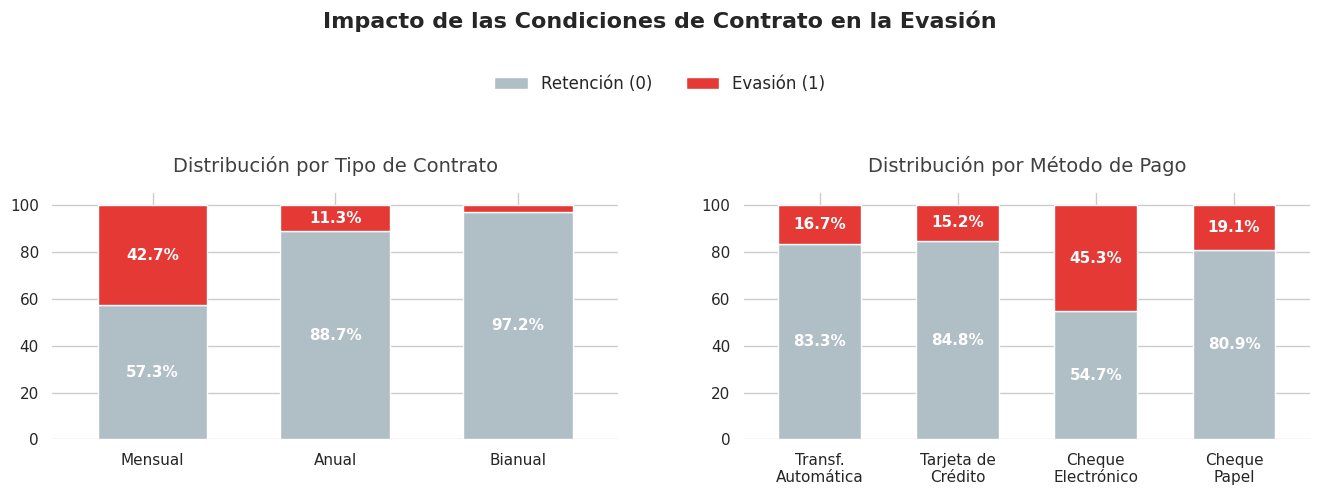




Resumen de Churn por: TIPO DE CONTRATO


,Total Clientes,Retenidos (0),Evadidos (1),Tasa de Evasión
Mensual,3875,2220,1655,42.71%
Anual,1473,1307,166,11.27%
Bianual,1695,1647,48,2.83%
Total General,7043,5174,1869,26.54%





Resumen de Churn por: MÉTODO DE PAGO


,Total Clientes,Retenidos (0),Evadidos (1),Tasa de Evasión
Transf. Automática,1544,1286,258,16.71%
Tarjeta de Crédito,1522,1290,232,15.24%
Cheque Electrónico,2365,1294,1071,45.29%
Cheque Papel,1612,1304,308,19.11%
Total General,7043,5174,1869,26.54%


In [23]:
print("CONTRATO Y PAGO VS. EVASIÓN")
print("===========================\n")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# variables y diccionarios a utilizar
vars_comerciales = ['contract', 'payment_method']

mapeo_comercial = {
    'contract': {'Month-to-month': 'Mensual', 'One year': 'Anual', 'Two year': 'Bianual'},
    'payment_method': {'Electronic check': 'Cheque\nElectrónico', 'Mailed check': 'Cheque\nPapel',
                       'Bank transfer (automatic)': 'Transf.\nAutomática',
                       'Credit card (automatic)': 'Tarjeta de\nCrédito'}
}

titulos_comercial = {'contract': 'Tipo de Contrato', 'payment_method': 'Método de Pago'}
colores_alerta = ['#B0BEC5', '#E53935']

# Crear GRÁFICO BARRAS
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
fig.suptitle('Impacto de las Condiciones de Contrato en la Evasión', fontsize=16, fontweight='bold', y=1.05)

for i, col in enumerate(vars_comerciales):
    # agrupación y normalización
    tabla_prop = pd.crosstab(df_telecom[col], df_telecom['churn'], normalize='index') * 100

    # mapear nombres para el eje X
    if col in mapeo_comercial:
        tabla_prop.index = tabla_prop.index.map(lambda x: mapeo_comercial[col].get(x, x))

    # crear gráfico
    tabla_prop.plot(kind='bar', stacked=True, color=colores_alerta, ax=axes[i], legend=False, width=0.6)

    # estética gráfico
    axes[i].set_title(f'Distribución por {titulos_comercial[col]}', fontsize=14, pad=15, color='#404040')
    axes[i].set(ylabel=None, xlabel=None)
    axes[i].tick_params(axis='x', rotation=0, labelsize=11)
    sns.despine(ax=axes[i], left=True, bottom=True)

    # porcentajes en barras
    for p in axes[i].patches:
        ancho, alto = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if alto > 5:
            axes[i].text(x + ancho/2, y + alto/2, f'{alto:.1f}%',
                         ha='center', va='center', color='white', fontweight='bold', fontsize=11)

fig.legend(['Retención (0)', 'Evasión (1)'], loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, frameon=False, fontsize=12)
plt.tight_layout(pad=3.0, w_pad=5.0)
plt.show()


# TABLAS DE RESUMEN
for col in vars_comerciales:
    print(f"\n\n\nResumen de Churn por: {titulos_comercial[col].upper()}")

    # tabla cruzada con Totales absolutos
    resumen = pd.crosstab(df_telecom[col], df_telecom['churn'], margins=True, margins_name='Total General')
    resumen.columns = ['Retenidos (0)', 'Evadidos (1)', 'Total Clientes']

    # Reordenar y calcular porcentaje
    resumen = resumen[['Total Clientes', 'Retenidos (0)', 'Evadidos (1)']]
    resumen['Tasa de Evasión'] = (resumen['Evadidos (1)'] / resumen['Total Clientes'] * 100).round(2).astype(str) + '%'

    # Insertar nombres legibles
    if col in mapeo_comercial:
        resumen.index = [mapeo_comercial[col].get(x, x).replace('\n', ' ') if x != 'Total General' else x for x in resumen.index]

    display(resumen)

**Conclusiones - Características del Contrato:**

* **Tipo de Contrato:** se observa una clara relación entre el tipo de contrato y la retención. Los clientes con contratos mensuales presentan una tasa de evasión considerablemente más alta. El análisis poblacional muestra que la mayoría de los clientes posee este tipo de contrato, por lo que este grupo concentra la mayor parte de los abandonos de la compañía. En contraste, aquellos con contratos a 1 o 2 años muestran niveles de abandono mucho menores.

* **Método de Pago:** los clientes que pagan mediante "Cheque Electrónico" muestran una tasa de evasión mucho más alta en comparación con quienes utilizan métodos automáticos (tarjeta de crédito o transferencia). La mayor retención en los métodos automatizados podría estar asociada a una mayor facilidad y continuidad en el proceso de pago.


#### 3.3.3 Churn por Servicios de Internet Contratados

Se analiza el impacto que tiene el tipo de servicio de tecnológico contratado en la retención de los clientes. Se busca identificar si existe algún tipo de servicio de internet con mayor influencia en el abandono, lo cual podría señalar posibles problemas de calidad o de precio en esa tecnología en comparación con las otras opciones del mercado.



CONTEXTO POBLACIONAL



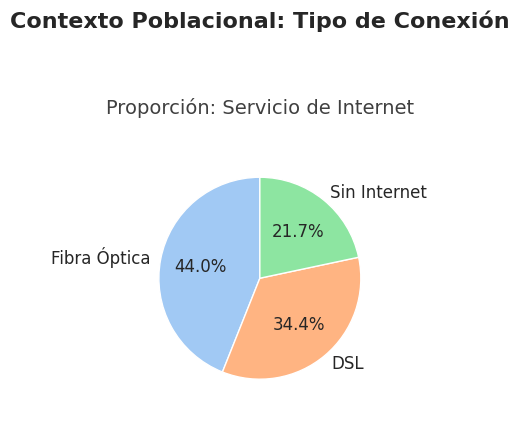

In [24]:
print("CONTEXTO POBLACIONAL")
print("====================\n")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Variables y diccionarios
vars_internet = ['internet_service']

mapeo_internet = {
    'internet_service': {'DSL': 'DSL', 'Fiber optic': 'Fibra Óptica', 'No': 'Sin Internet'}
}

titulos_internet = {'internet_service': 'Servicio de Internet'}
colores_pie_internet = sns.color_palette("pastel")[0:3]

# Crear GRÁFICO TORTA
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Contexto Poblacional: Tipo de Conexión', fontsize=16, fontweight='bold', y=0.92)

conteo = df_telecom['internet_service'].value_counts()
etiquetas = [mapeo_internet['internet_service'].get(x, x) for x in conteo.index]

ax.pie(conteo, labels=etiquetas, autopct='%1.1f%%', startangle=90, radius=0.8,
       colors=colores_pie_internet, wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 12})
ax.set_title(f"Proporción: {titulos_internet['internet_service']}", fontsize=14, pad=5, color='#404040')

plt.tight_layout(pad=2.0, rect=[0, 0, 1, 0.92])
plt.show()

SERVICIO DE INTERNET VS. EVASIÓN



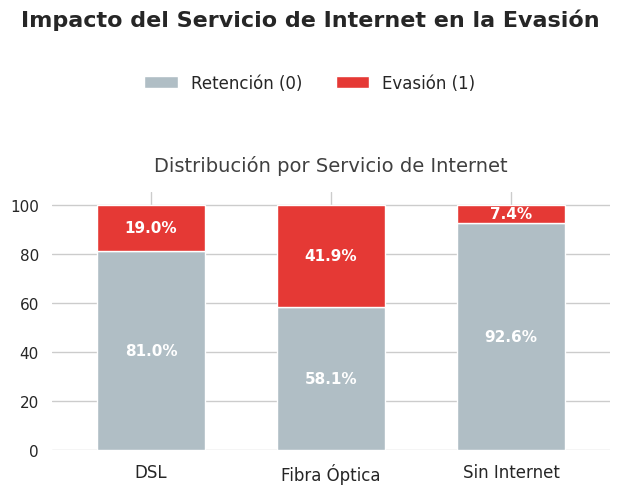




Resumen de Churn por: SERVICIO DE INTERNET


,Total Clientes,Retenidos (0),Evadidos (1),Tasa de Evasión
DSL,2421,1962,459,18.96%
Fibra Óptica,3096,1799,1297,41.89%
Sin Internet,1526,1413,113,7.4%
Total General,7043,5174,1869,26.54%


In [25]:
print("SERVICIO DE INTERNET VS. EVASIÓN")
print("================================\n")

colores_alerta = ['#B0BEC5', '#E53935']

# Crear GRÁFICO BARRAS
# Tamaño (7, 5) proporcional al (14, 5) que usamos para dos gráficos en la sección de contratos
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Impacto del Servicio de Internet en la Evasión', fontsize=16, fontweight='bold', y=1.05)

# Agrupación y normalización
tabla_prop = pd.crosstab(df_telecom['internet_service'], df_telecom['churn'], normalize='index') * 100

# Mapear nombres para el eje X
tabla_prop.index = tabla_prop.index.map(lambda x: mapeo_internet['internet_service'].get(x, x))

# Crear gráfico
tabla_prop.plot(kind='bar', stacked=True, color=colores_alerta, ax=ax, legend=False, width=0.6)

# Estética gráfico
ax.set_title(f"Distribución por {titulos_internet['internet_service']}", fontsize=14, pad=15, color='#404040')
ax.set(ylabel=None, xlabel=None)
ax.tick_params(axis='x', rotation=0, labelsize=12)
sns.despine(ax=ax, left=True, bottom=True)

# Porcentajes en barras
for p in ax.patches:
    ancho, alto = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if alto > 5:
        ax.text(x + ancho/2, y + alto/2, f'{alto:.1f}%',
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

fig.legend(['Retención (0)', 'Evasión (1)'], loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, frameon=False, fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

# TABLA DE RESUMEN
print(f"\n\n\nResumen de Churn por: {titulos_internet['internet_service'].upper()}")

# Tabla cruzada con Totales absolutos
resumen = pd.crosstab(df_telecom['internet_service'], df_telecom['churn'], margins=True, margins_name='Total General')
resumen.columns = ['Retenidos (0)', 'Evadidos (1)', 'Total Clientes']

# Reordenar y calcular porcentaje
resumen = resumen[['Total Clientes', 'Retenidos (0)', 'Evadidos (1)']]
resumen['Tasa de Evasión'] = (resumen['Evadidos (1)'] / resumen['Total Clientes'] * 100).round(2).astype(str) + '%'

# Insertar nombres legibles
resumen.index = [mapeo_internet['internet_service'].get(x, x) if x != 'Total General' else x for x in resumen.index]

display(resumen)

**Conclusiones - Servicio de Internet:**
* **Fibra Óptica:** a pesar de ser el servicio con mayor base de clientes, presenta la tasa de evasión más alta. Esto podría indicar problemas de calidad de servicio, precio poco competitivo frente al mercado, o falsas expectativas generadas durante la venta.
* **Sin Internet:** los clientes que solo consumen telefonía son extremadamente leales y tienen la tasa de fuga más baja.

### 3.4 Análisis de Evasión por Variables Numéricas

Se explora cómo se distribuye la evasión en función de las variables cuantitativas de los clientes. Se utilizan estadísticas descriptivas, gráficos de distribución y boxplots para identificar patrones que diferencien a los clientes que abandonan de aquellos que permanecen.

Se analizarán las siguientes variables:
- **Antigüedad (`tenure`)**: cantidad de meses que el cliente lleva en la empresa.
- **Cargo Mensual (`monthly_charges`)**: monto que el cliente paga mes a mes  .
- **Cargo Total (`total_charges`)**: dinero total acumulado que el cliente ha gastado.
- **Gasto Diario Estimado (`cuentas_diarias`)**: aproximación del gasto diario que paga el cliente.

#### 3.4.1 Distribución General de Variables Numéricas

Se presenta un panorama comparativo de las cuatro variables cuantitativas principales para identificar diferencias entre clientes que abandonan y los que permanecen.

DISTRIBUCIÓN VARIABLES NUMÉRICAS



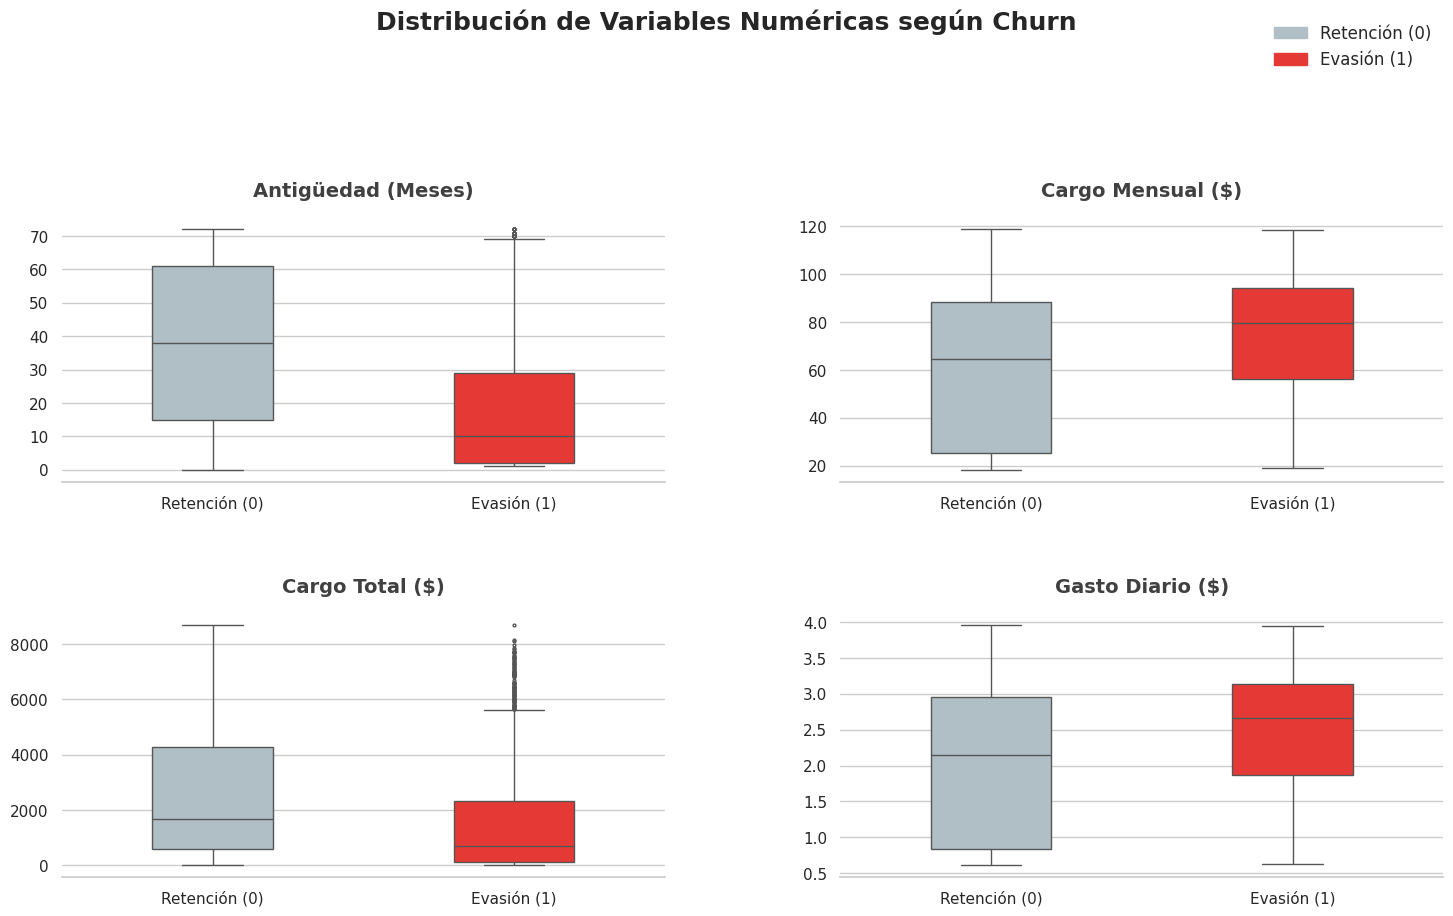



TABLA RESUMEN: ESTADÍSTICAS POR GRUPO



Retención (0)  Evasión (1)
1. Antigüedad (meses) Mediana (Central)          38.00        10.00
                      Promedio                   37.57        17.98
2. Cargo Mensual ($)  Mediana (Central)          64.43        79.65
                      Promedio                   61.27        74.44
3. Cargo Total ($)    Mediana (Central)        1679.52       703.55
                      Promedio                 2549.91      1531.80
4. Gasto Diario ($)   Mediana (Central)           2.15         2.66
                      Promedio                    2.04         2.48

In [26]:
print("DISTRIBUCIÓN VARIABLES NUMÉRICAS")
print("=================================\n")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

vars_numericas = ['tenure', 'monthly_charges', 'total_charges', 'cuentas_diarias']
colores_alerta = ['#B0BEC5', '#E53935']

titulos_num = {
    'tenure': 'Antigüedad (Meses)',
    'monthly_charges': 'Cargo Mensual ($)',
    'total_charges': 'Cargo Total ($)',
    'cuentas_diarias': 'Gasto Diario ($)'
}

# lienzo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
fig.suptitle('Distribución de Variables Numéricas según Churn', fontsize=18, fontweight='bold', y=0.98)

axes = axes.flatten()
for i, col in enumerate(vars_numericas):
    sns.boxplot(data=df_telecom, x='churn', y=col, hue='churn', palette=colores_alerta,
                ax=axes[i], width=0.4, fliersize=2, saturation=1, legend=False)

    axes[i].set_title(titulos_num[col], fontsize=14, fontweight='bold', pad=15, color='#404040')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
    sns.despine(ax=axes[i], left=True)

# leyenda global
leyenda_ret = mpatches.Patch(color='#B0BEC5', label='Retención (0)')
leyenda_ev = mpatches.Patch(color='#E53935', label='Evasión (1)')
fig.legend(handles=[leyenda_ret, leyenda_ev], loc='upper right', bbox_to_anchor=(0.95, 0.98), fontsize=12, frameon=False)

plt.tight_layout(pad=5.0, w_pad=8.0, h_pad=4.0)
plt.show()



# TABLA RESUMEN
print("\n\nTABLA RESUMEN: ESTADÍSTICAS POR GRUPO\n")
resumen_num = df_telecom.groupby('churn')[vars_numericas].agg(['median', 'mean']).T
resumen_num.columns = ['Retención (0)', 'Evasión (1)']

rename_vars = {'tenure': '1. Antigüedad (meses)', 'monthly_charges': '2. Cargo Mensual ($)', 'total_charges': '3. Cargo Total ($)', 'cuentas_diarias': '4. Gasto Diario ($)'}
resumen_num = resumen_num.rename(index=rename_vars, level=0)
resumen_num = resumen_num.rename(index={'median': 'Mediana (Central)', 'mean': 'Promedio'}, level=1)

display(resumen_num.round(2))

#### 3.4.2 Antigüedad del Cliente (Tenure)

La antigüedad representa la cantidad de meses que el cliente lleva en la empresa. Analizar la distribución de esta variable permite detectar en qué etapa del ciclo de vida se produce la mayor fuga.

HISTOGRAMA DE ANTIGÜEDAD VS. EVASIÓN



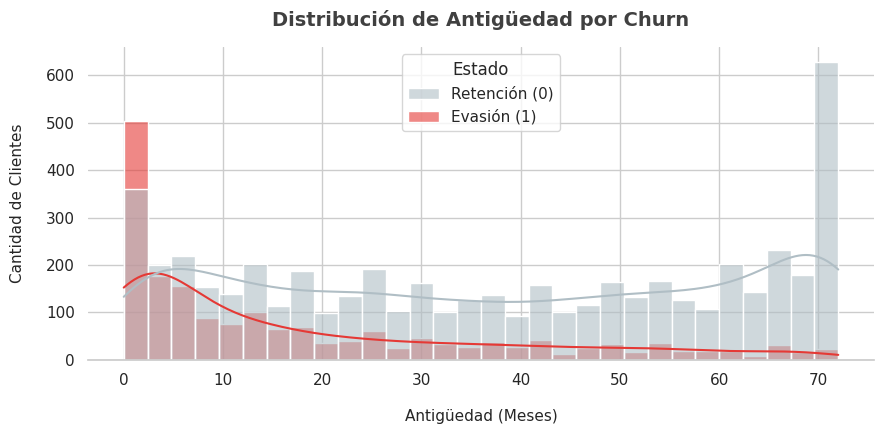


Estadísticas de Antigüedad:
  • Promedio Retención: 37.6 meses
  • Promedio Evasión: 18.0 meses

Análisis del punto máximo de Abandono:
  • Mes con mayor evasión: Mes 1
  • Volumen de pérdida en el mes 1: 380 clientes (20.3% del total de evasión)


In [27]:
print("HISTOGRAMA DE ANTIGÜEDAD VS. EVASIÓN")
print("==================================\n")

fig, ax = plt.subplots(figsize=(9, 4.5))

# Histograma con curva de densidad
sns.histplot(data=df_telecom, x='tenure', hue='churn', palette=colores_alerta,
             bins=30, kde=True, alpha=0.6, ax=ax)

ax.set_title('Distribución de Antigüedad por Churn', fontsize=14, fontweight='bold', pad=15, color='#404040')
ax.set_xlabel('Antigüedad (Meses)', fontsize=11, labelpad=15)
ax.set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=15)

# ajuste de leyenda
leyenda = ax.get_legend()
if leyenda:
    leyenda.set_title('Estado')
    for t, l in zip(leyenda.texts, ['Retención (0)', 'Evasión (1)']):
        t.set_text(l)

sns.despine(left=True)
plt.tight_layout()
plt.show()



# calcular estadísticas: media y valor máximo
df_evasion = df_telecom[df_telecom['churn']==1]
df_retencion = df_telecom[df_telecom['churn']==0]
media_ret = df_retencion['tenure'].mean()
media_ev = df_evasion['tenure'].mean()

# obtener mes con mayor evasion
mes_pico_ev = df_evasion['tenure'].mode()[0]
cantidad_pico_ev = df_evasion['tenure'].value_counts()[mes_pico_ev]
porcentaje_pico = (cantidad_pico_ev / df_evasion.shape[0]) * 100

# mostrar resultados
print(f"\nEstadísticas de Antigüedad:")
print(f"  • Promedio Retención: {media_ret:.1f} meses")
print(f"  • Promedio Evasión: {media_ev:.1f} meses")
print(f"\nAnálisis del punto máximo de Abandono:")
print(f"  • Mes con mayor evasión: Mes {mes_pico_ev}")
print(f"  • Volumen de pérdida en el mes {mes_pico_ev}: {cantidad_pico_ev} clientes ({porcentaje_pico:.1f}% del total de evasión)")


**Conclusión - Antigüedad:**

Los clientes que abandonan el servicio tienen una antigüedad promedio mucho menor (\~18 meses) que aquellos que permanecen (\~38 meses). Sin embargo, el dato central del análisis se observa al inicio del contrato: la mayor concentración de bajas se registra en el mes 1. Este es el único período donde la cantidad de cancelaciones logra superar a las retenciones.

Esto sugiere que las cancelaciones tempranas podrían estar influenciadas por problemas en las primeras etapas de la experiencia del cliente (como la instalación, el alta del servicio o el primer cobro), o bien, porque el servicio real entregado no logró cumplir con las expectativas iniciales generadas durante el proceso de venta



#### 3.4.3 Variables de Gasto (Mensual, Total y Diario)

Se evalúan las métricas financieras para comprender si el volumen de facturación influye en la decisión de cancelar el contrato.

HISTOGRAMAS DE VARIABLES DE GASTO VS. EVASIÓN



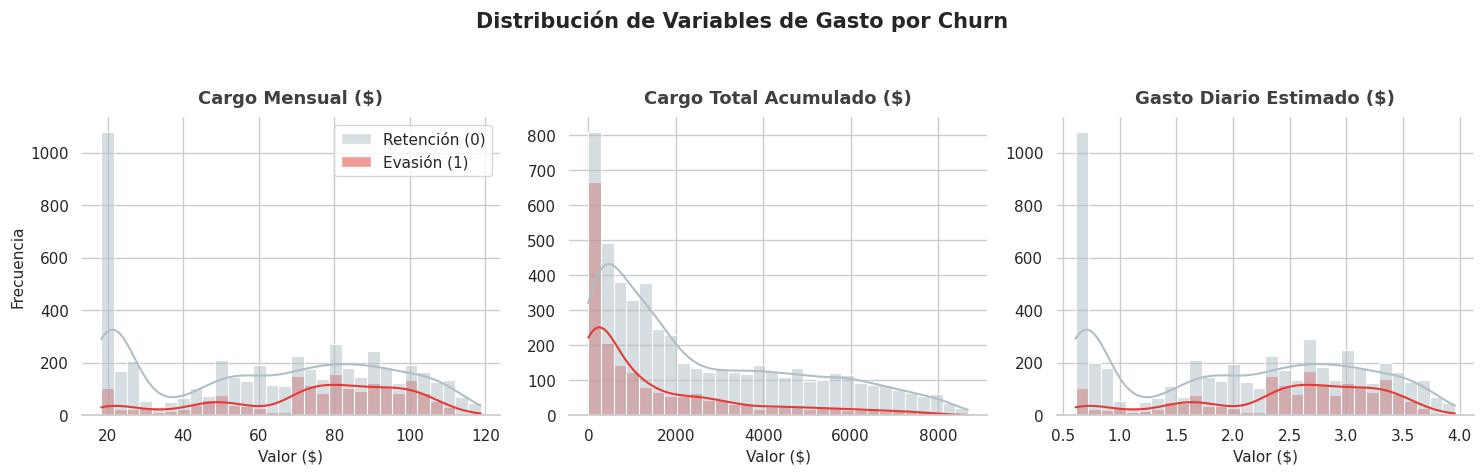


Estadísticas de Gasto (Promedios):
  • Cargo Mensual: Retención $61.27  |  Evasión $74.44
  • Gasto Diario : Retención $2.04   |  Evasión $2.48
  • Cargo Total  : Retención $2549.91 |  Evasión $1531.80


In [28]:
print("HISTOGRAMAS DE VARIABLES DE GASTO VS. EVASIÓN")
print("=============================================\n")

vars_gasto = ['monthly_charges', 'total_charges', 'cuentas_diarias']
titulos_gasto = ['Cargo Mensual ($)', 'Cargo Total Acumulado ($)', 'Gasto Diario Estimado ($)']
colores_alerta = ['#B0BEC5', '#E53935']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Distribución de Variables de Gasto por Churn', fontsize=15, fontweight='bold', y=1.05)

for i, var in enumerate(vars_gasto):
    sns.histplot(data=df_telecom, x=var, hue='churn', palette=colores_alerta,
                 bins=30, kde=True, alpha=0.5, ax=axes[i], legend=(i==0))

    axes[i].set_title(titulos_gasto[i], fontsize=13, fontweight='bold', pad=10, color='#404040')
    axes[i].set_xlabel('Valor ($)', fontsize=11)
    axes[i].set_ylabel('Frecuencia' if i == 0 else '', fontsize=11)
    sns.despine(ax=axes[i], left=True)

    # leyenda (en 1° grpafico)
    if i == 0:
        leyenda = axes[0].get_legend()
        if leyenda:
            leyenda.set_title('')
            for t, l in zip(leyenda.texts, ['Retención (0)', 'Evasión (1)']):
                t.set_text(l)

plt.tight_layout()
plt.show()

# calcular datos estadísticos
df_evasion = df_telecom[df_telecom['churn']==1]
df_retencion = df_telecom[df_telecom['churn']==0]

print(f"\nEstadísticas de Gasto (Promedios):")
print(f"  • Cargo Mensual: Retención ${df_retencion['monthly_charges'].mean():.2f}  |  Evasión ${df_evasion['monthly_charges'].mean():.2f}")
print(f"  • Gasto Diario : Retención ${df_retencion['cuentas_diarias'].mean():.2f}   |  Evasión ${df_evasion['cuentas_diarias'].mean():.2f}")
print(f"  • Cargo Total  : Retención ${df_retencion['total_charges'].mean():.2f} |  Evasión ${df_evasion['total_charges'].mean():.2f}")

**Conclusión - Variables de Gasto:**

* **Cargo Mensual y Gasto Diario:** Se observa que los clientes que abandonan el servicio pagan una cuota mensual promedio más alta ($74.44) en comparación con los usuarios que permanecen activos ($61.27). Esto podría estar indicando que la tasa de cancelación es mayor en los planes más costosos/premium que en los económicos.

* **Cargo Total:** la mayor evasión se da en los grupos un gasto histórico acumulado considerablemente ($1531.80 frente a $2549.91). Este resultado parece ser una consecuencia directa de su baja antigüedad: los clientes que abandonan el contrato de forma temprana no logran acumular un valor de gasto significativo a largo plazo.


**Resumen del Análisis Numérico:**

El perfil demográfico y comercial de **mayor riesgo** parece apuntar a los clientes nuevos (menos de 12 meses de antigüedad) que contratan planes de alto costo. La combinación de una facturación mensual elevada y una salida rápida en los primeros meses sugiere que el servicio entregado no logra justificar su precio o cumplir con las expectativas iniciales del usuario, provocando la cancelación inmediata antes de generar rentabilidad real para la compañía.

### 3.5 Análisis de Correlación

Para cerrar la fase exploratoria, se analiza la relación entre las variables numéricas y la cancelación del servicio (`churn`) mediante una matriz de correlación de Pearson.

Como paso adicional, se crea una nueva variable llamada **"Cantidad de Servicios"** (`cantidad_servicios`) para medir qué tan integrado está el cliente con la empresa. Esta métrica suma los servicios extra de internet que tiene contratados cada usuario, a partir de estas 6 opciones:
1. Seguridad en línea (`online_security`)
2. Respaldo en línea (`online_backup`)
3. Protección de dispositivo (`device_protection`)
4. Soporte técnico (`tech_support`)
5. Televisión (`streaming_tv`)
6. Streaming de películas (`streaming_movies`)

MATRIZ DE CORRELACIÓN: VARIABLES NUMÉRICAS Y SERVICIOS VS. EVASIÓN



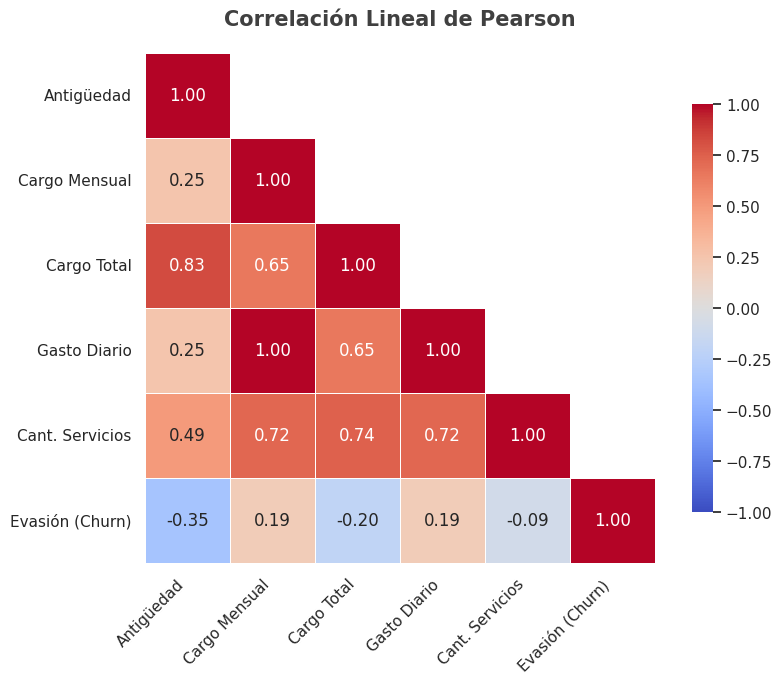


RANKING DE CORRELACIÓN CON LA EVASIÓN (CHURN)

  • Gasto Diario   : +0.193
  • Cargo Mensual  : +0.193
  • Cant. Servicios: -0.088
  • Cargo Total    : -0.198
  • Antigüedad     : -0.352


In [29]:
print("MATRIZ DE CORRELACIÓN: VARIABLES NUMÉRICAS Y SERVICIOS VS. EVASIÓN")
print("===================================================================\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la variable "Cantidad de Servicios"
cols_servicios = ['online_security', 'online_backup', 'device_protection',
                  'tech_support', 'streaming_tv', 'streaming_movies']

# Sumamos 1 por cada servicio activo
df_telecom['cantidad_servicios'] = df_telecom[cols_servicios].apply(lambda x: x.isin([1, 'Yes', 'Si', 'Sí'])).sum(axis=1)

# 2. Seleccionar variables para la correlación
vars_corr = ['tenure', 'monthly_charges', 'total_charges', 'cuentas_diarias', 'cantidad_servicios', 'churn']

# Diccionario para nombres legibles
nombres_corr = {
    'tenure': 'Antigüedad',
    'monthly_charges': 'Cargo Mensual',
    'total_charges': 'Cargo Total',
    'cuentas_diarias': 'Gasto Diario',
    'cantidad_servicios': 'Cant. Servicios',
    'churn': 'Evasión (Churn)'
}

# 3. Calcular matriz de correlación
matriz_corr = df_telecom[vars_corr].corr()
matriz_corr = matriz_corr.rename(columns=nombres_corr, index=nombres_corr)

# 4. Configurar el lienzo y la máscara (con k=1 para mantener la diagonal y evitar la columna vacía)
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)

# 5. Generar el Mapa de Calor
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .8}, ax=ax)

ax.set_title("Correlación Lineal de Pearson", fontsize=15, fontweight='bold', pad=20, color='#404040')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# --- NUEVO: MOSTRAR LOS VALORES NUMÉRICOS EXACTOS ---
print("\nRANKING DE CORRELACIÓN CON LA EVASIÓN (CHURN)")
print("=============================================\n")

# Filtramos solo la columna de Churn, sacamos la correlación consigo misma (1.0) y ordenamos
corr_churn = matriz_corr['Evasión (Churn)'].drop('Evasión (Churn)').sort_values(ascending=False)

for index, value in corr_churn.items():
    # Formateamos para que se vea claro si es positiva o negativa
    signo = "+" if value > 0 else ""
    print(f"  • {index.ljust(15)}: {signo}{value:.3f}")

**Conclusión - Análisis de Correlación:**

* **Antigüedad vs. Evasión (-0.352):** existe una correlación negativa moderada (visible en tonos azules) entre la antigüedad y la evasión. Esto confirma lo observado en secciones anteriores: a mayor tiempo de permanencia del cliente en la empresa, menor es la probabilidad de que cancele el servicio.

* **Cargos vs. Evasión (+0.193):** el costo diario y gasto mensual presentan una correlación positiva leve (visible en tonos cálidos) con la tasa de abandono. Esto corrobora numéricamente que los planes más costosos tienen cierta influencia en la salida temprana de clientes.

* **Cantidad de Servicios vs. Evasión (-0.088):** se observa una correlación negativa débil (tonos celestes claros) entre los servicios extra contratados y la evasión. Si bien tener más adiciones ayuda a integrar al cliente y reducir las bajas, su peso estadístico es bastante menor comparado con el impacto del precio o la antigüedad.

También se observa una alta correlación positiva entre la antigüedad y el cargo total acumulado, lo cual es lógico ya que a más meses de contrato, mayor es la facturación histórica. Del mismo modo, el gasto diario y el cargo mensual presentan una correlación perfecta (1.00) porque son la misma métrica calculada de distinta forma.

##📄4. Informe final

### 4.1 Introducción

Telecom X es una empresa de telecomunicaciones que se encuentra enfrentando un alto índice de evasión de clientes (Churn). El objetivo de este proyecto es recopilar, procesar y analizar la información histórica de la compañía para comprender los factores comerciales, demográficos y económicos que motivan esta pérdida de usuarios.

A través de este análisis exploratorio de datos (EDA), se busca proveer al equipo de Data Science un conjunto de datos limpio y estructurado, junto con insights estratégicos que permitan orientar el desarrollo de modelos predictivos y aplicar acciones concretas para reducir la tasa de cancelación.

<br>

**Dataset analizado:** 7,043 clientes con información demográfica, contractual, servicios contratados y datos de facturación.

<br>

### 4.2 Limpieza y Tratamiento de Datos

Se realizó un proceso de preparación de los datos (ETL) para asegurar la calidad de la información antes del análisis. Se ejecutaron los siguientes pasos:

* **Extracción y Normalización:** se importaron los datos en formato JSON desde la API proporcionada. Dado que el archivo original poseía estructuras anidadas, se aplicó un proceso de normalización para transformarlo en un DataFrame tabular de Pandas, resultando en 7267 registros.

* **Estandarización:** se renombraron las columnas eliminando prefijos innecesarios para facilitar su manipulación. Las variables categóricas binarias (como "Yes/No" o "Female/Male") se convirtieron a un formato numérico (1/0) para optimizar el análisis matemático.

* **Manejo de Inconsistencias y Nulos:** se eliminaron 224 registros (aprox. 3% del total) que presentaban valores vacíos en la variable objetivo (`churn`), para así evitar futuros sesgos en el análisis.
  * Se identificaron 11 registros con valores vacíos en el gasto total acumulado(`total_charges`). Al comprobar que correspondían a clientes nuevos con antigüedad cero (`tenure = 0`), se reemplazaron esos valores con `0` y luego se ajustó el tipo de dato de la columna a numérico.

* **Creación de nuevas Variables:** para profundizar el análisis se crearon dos nuevas métricas: el costo diario (`cuentas_diarias`) dividiendo la facturación mensual por 30, y la `cantidad_servicios` que suma los servicios adicionales de internet contratados por cada cliente.

### 4.3 Análisis Exploratorio de Datos

A través de la estadística descriptiva y las visualizaciones, se evaluó el comportamiento de la base de clientes (con una tasa de evasión general del **26.54%**), identificando los siguientes patrones:

<br>

**Factores con MAYOR impacto en la evasión:**

| Factor | Segmento de Alto Riesgo | Tasa de Churn |
|--------|-------------------------|---------------|
| **Tipo de Contrato** | Month-to-month | 42.7% |
| **Servicio Internet** | Fibra Óptica | 41.9% |
| **Método de Pago** | Cheque Electrónico | 45.3% |
| **Antigüedad** | <12 meses | >40% |

<br>

**Análisis por categoría:**

* **Perfil Demográfico:** el género no mostró influencia en la cancelación. Por otro lado, los adultos mayores y los clientes sin pareja tienen una mayor propensión a abandonar el servicio, aunque ambos grupos no representan la mayoría absoluta del volumen de la compañía.

* **Contrato y Pagos:** se observó una clara tendencia de abandono en los clientes con **contratos de renovación mensual** y en aquellos que utilizan el **Cheque Electrónico** como método de pago (alcanzando un 45.29% de churn en este segmento).

* **Servicio de Internet:** el servicio más avanzado y masivo, la **Fibra Óptica**, concentra la tasa de evasión más alta frente al servicio de DSL o a los clientes que solo poseen telefonía.

* **Impacto Numérico:** El análisis de correlación y los histogramas demostraron que la **antigüedad** es el factor de retención más fuerte. El momento crítico ocurre durante el **primer mes** de contrato, donde el volumen de evasión supera a los clientes retenidos. A su vez, los clientes que se dan de baja tienden a pagar cuotas mensuales promedio más altas (\$74.44 frente a \$61.27).

### 4.4 Conclusiones e Insights

El análisis de la información permite identificar un perfil claro de cliente con mayor riesgo de abandono: **usuarios nuevos (especialmente en su primer mes), que contratan planes costosos (Fibra Óptica), con contratos de modalidad mensual y pago vía cheque electrónico.**

<br>

Los principales hallazgos del análisis son:

* **Problemas en el inicio del servicio**: la gran cantidad de cancelaciones tempranas concentradas en el prime mes sugiere aque existen fallas directas en la primera experiencia del usuario, que podrían deberse a demoras en la instalación, problemas técnicos iniciales o una mala gestión en la primera facturación.

* **El producto no cumple las expectativas**: la alta tasa de cancelación en los planes más caros (Fibra Óptica) indica que el valor real entregado por el servicio no logra justificar su precio ni cumplir con las promesas generadas durante el proceso de venta.

* **Falta de servicios adicionales:** aunque los usuarios que se dan de baja tienden a pagar facturas mensuales más altas (por el elevado costo base de la Fibra Óptica), el análisis demostró que suelen tener muy pocos servicios extra contratados (como seguridad, soporte o TV). Al contar solo con el internet básico, no tienen complementos que los integren al ecosistema de la empresa, lo que elimina las barreras de retención y facilita su decisión de cambiar de proveedor rápidamente.

<br>



### 4.5 Recomendaciones

Con base en los datos analizados, se proponen las siguientes iniciativas estratégicas para mejorar la retención de clientes:

* **Auditar la Experiencia Inicial:** es importante revisar qué está fallando en los procesos de instalación y atención al cliente durante los primeros 30 días. Hay que prestar especial atención a los nuevos usuarios de Fibra Óptica para asegurar que reciban la calidad de servicio prometido por el que están pagando.


* **Promover contratos anuales:** se recomienda ofrecer promociones o descuentos temporales a los nuevos clientes y a aquellos que están en la modalidad mensual, para motivarlos a cambiar hacia un contrato más fijo de 1 o 2 años.


* **Impulsar la automatización de pagos:** se sugiere dar beneficios o incentivos para que los usuarios que pagan con Cheque Electrónico se adhieran al débito automático o tarjeta de crédito. Los datos muestran que automatizar el cobro reduce enormemente las cancelaciones del servicio.


* **Ofrecer servicios adicionales:** es importante armar paquetes atractivos que incluyan servicios extra como seguridad online, backup o TV para fomentar su suscripción. Consumir una mayor cantidad de productos ayudaría a aumentar el valor percibido por el cliente, haciendo que le sea más difícil tomar la decisión de abandonar la compañía.



### 4.5 Recomendaciones

Con base en los datos analizados, se proponen las siguientes iniciativas estratégicas priorizadas por impacto esperado:

**🎯 Prioridad ALTA** (impacto estimado: 10-15 puntos de reducción en churn)

* **Auditar la Experiencia Inicial:** revisar qué está fallando en los procesos de instalación y atención durante los primeros 30 días. Prestar especial atención a nuevos usuarios de Fibra Óptica para asegurar que reciban la calidad prometida.

* **Promover contratos anuales:** ofrecer promociones o descuentos a nuevos clientes y usuarios en modalidad mensual para motivar el cambio hacia contratos de 1-2 años.

**🎯 Prioridad MEDIA** (impacto estimado: 5-8 puntos de reducción en churn)

* **Impulsar la automatización de pagos:** incentivar a usuarios con Cheque Electrónico a migrar a débito automático o tarjeta de crédito. Los datos muestran que automatizar el cobro reduce enormemente las cancelaciones.

* **Ofrecer servicios adicionales:** armar paquetes atractivos que incluyan servicios extra (seguridad online, backup, TV) para aumentar el valor percibido y disminuir la posibilidad de abandono.